# Библиотеки

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from config import config

# Чтение данных

In [2]:
train=pd.read_csv(config.paths.data.train)
test=pd.read_csv(config.paths.data.test)

# Статистика
## Размер данных


In [3]:
print("Размер обучающей",train.shape)
print("Размер тестовой",test.shape)

Размер обучающей (1460, 81)
Размер тестовой (1459, 80)


## Обзор структуры


In [4]:
print("Обучающая\n")
print(train.info())
print("\n\nТестовая\n")
print(test.info())

Обучающая

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Описательная статистика численных

In [5]:
print(train.describe().T)

                count           mean           std      min        25%  \
Id             1460.0     730.500000    421.610009      1.0     365.75   
MSSubClass     1460.0      56.897260     42.300571     20.0      20.00   
LotFrontage    1201.0      70.049958     24.284752     21.0      59.00   
LotArea        1460.0   10516.828082   9981.264932   1300.0    7553.50   
OverallQual    1460.0       6.099315      1.382997      1.0       5.00   
OverallCond    1460.0       5.575342      1.112799      1.0       5.00   
YearBuilt      1460.0    1971.267808     30.202904   1872.0    1954.00   
YearRemodAdd   1460.0    1984.865753     20.645407   1950.0    1967.00   
MasVnrArea     1452.0     103.685262    181.066207      0.0       0.00   
BsmtFinSF1     1460.0     443.639726    456.098091      0.0       0.00   
BsmtFinSF2     1460.0      46.549315    161.319273      0.0       0.00   
BsmtUnfSF      1460.0     567.240411    441.866955      0.0     223.00   
TotalBsmtSF    1460.0    1057.429452  

## Описание категориальных

In [6]:
print(train.describe(include=object).T)

              count unique      top  freq
MSZoning       1460      5       RL  1151
Street         1460      2     Pave  1454
Alley            91      2     Grvl    50
LotShape       1460      4      Reg   925
LandContour    1460      4      Lvl  1311
Utilities      1460      2   AllPub  1459
LotConfig      1460      5   Inside  1052
LandSlope      1460      3      Gtl  1382
Neighborhood   1460     25    NAmes   225
Condition1     1460      9     Norm  1260
Condition2     1460      8     Norm  1445
BldgType       1460      5     1Fam  1220
HouseStyle     1460      8   1Story   726
RoofStyle      1460      6    Gable  1141
RoofMatl       1460      8  CompShg  1434
Exterior1st    1460     15  VinylSd   515
Exterior2nd    1460     16  VinylSd   504
MasVnrType      588      3  BrkFace   445
ExterQual      1460      4       TA   906
ExterCond      1460      5       TA  1282
Foundation     1460      6    PConc   647
BsmtQual       1423      4       TA   649
BsmtCond       1423      4       T

C:\Users\schab\AppData\Local\Temp\ipykernel_7492\3129425579.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(train.describe(include=object).T)


## Обзор пропущенных значений и дубликатов

In [7]:
pd.set_option('display.max_rows', None)
print("Train missing")
print(train.isnull().sum().to_string())
print("\n\nTest missing")
print(test.isnull().sum().to_string())

print("\n\nTrain duplicates")
print(train.duplicated().sum())
print("\n\nTest duplicates")
print(test.duplicated().sum())

Train missing
Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF          

# Графики


## Распределение цен

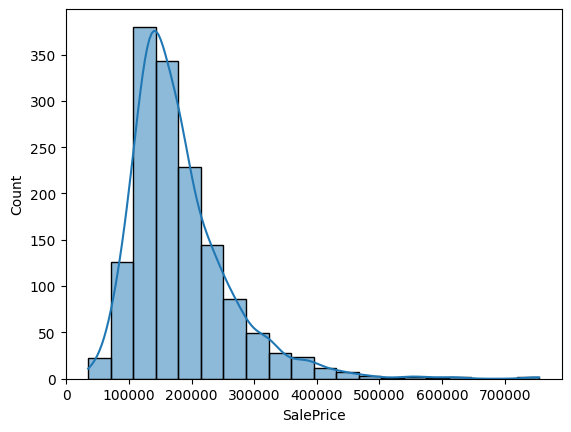

In [8]:

sns.histplot(train['SalePrice'],bins=20,kde=True)
plt.show()

## Логарифмированный вывод цены

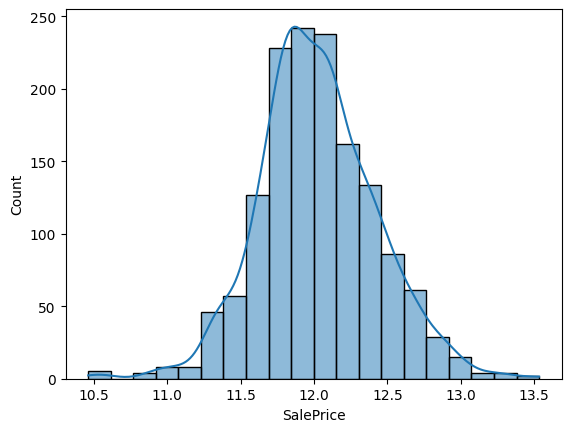

In [9]:
sns.histplot(np.log1p(train['SalePrice']),bins=20,kde=True)
plt.show()


## Выборосы в данных

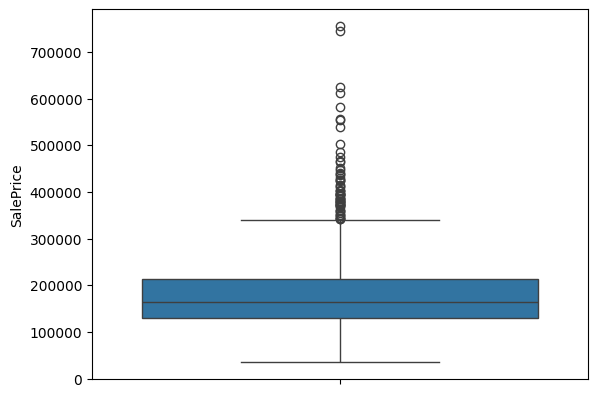

In [10]:
sns.boxplot(train['SalePrice'])
plt.show()

## Выбросы после логарифмирования

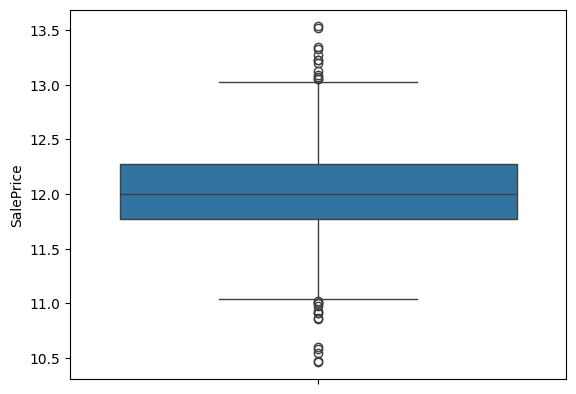

In [11]:
sns.boxplot(np.log1p(train['SalePrice']))
plt.show()

## Корреляция с ценой прожажи


<Axes: >

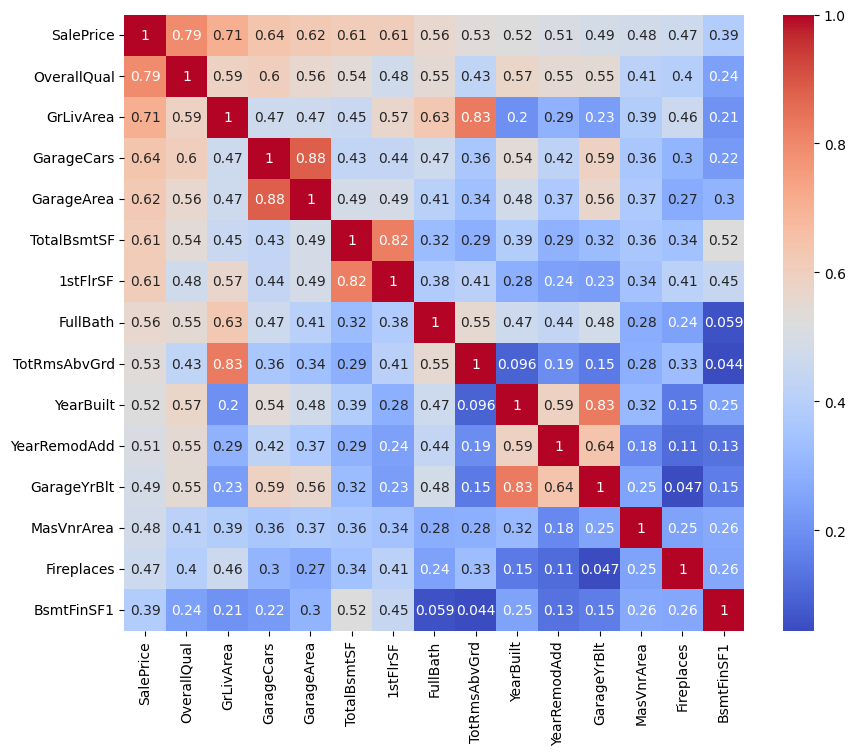

In [12]:
train_corr=train.copy()
num_cols = train_corr.select_dtypes(include=['number']).columns
corr = train_corr[num_cols].corr()
top_features = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 8))
sns.heatmap(train_corr[top_features].corr(), annot=True, cmap="coolwarm")

## Распределения переменных с самой высокой корреляцией с ценой продажи

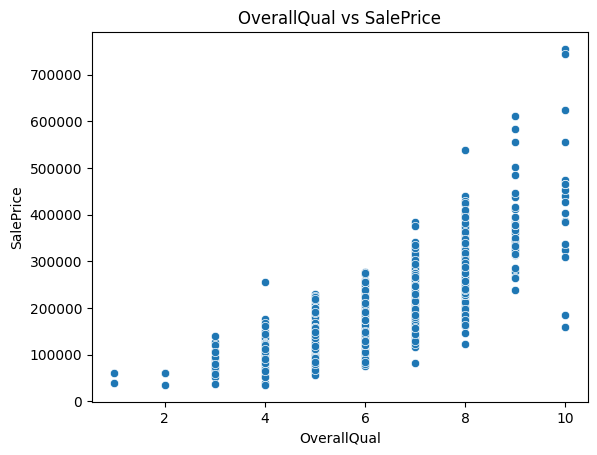

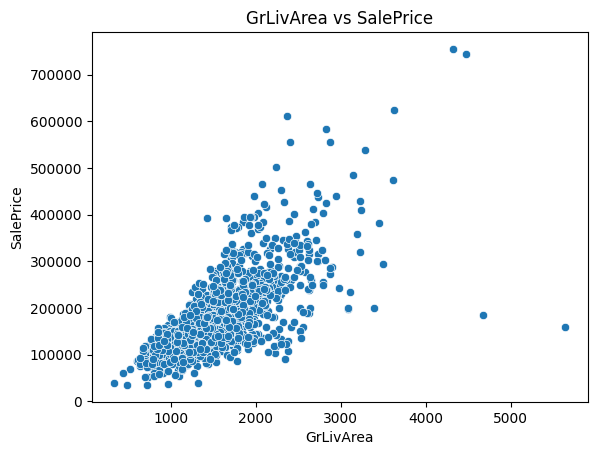

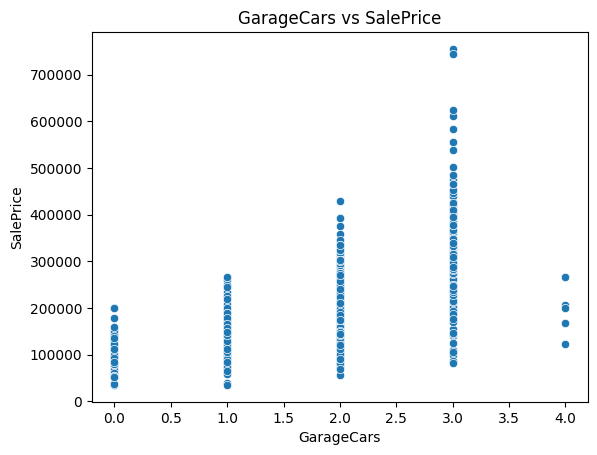

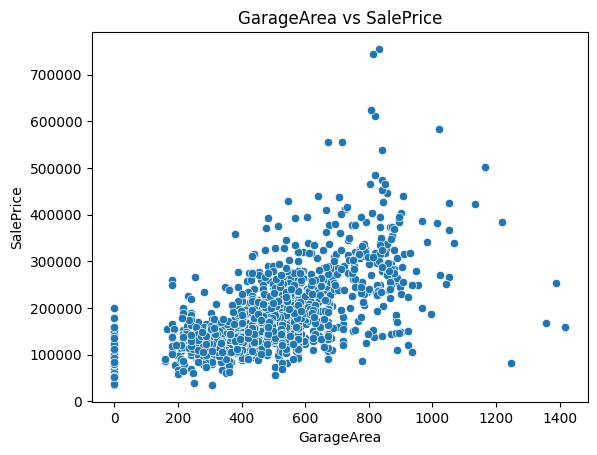

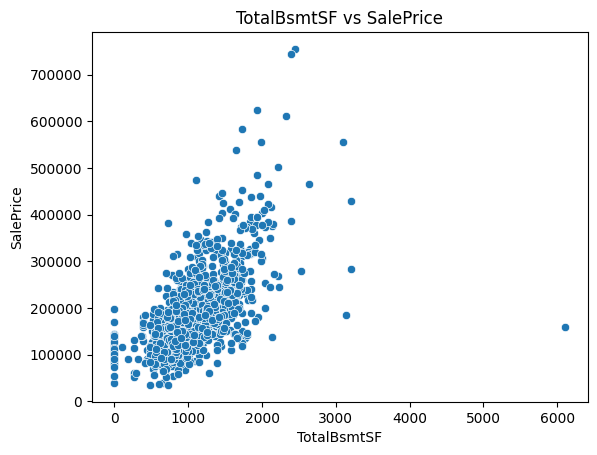

In [13]:

num_cols = train.select_dtypes(include=np.number).columns
corr = train[num_cols].corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = corr.drop('SalePrice').head(5).index
for col in top_features:
    sns.scatterplot(x=train[col], y=train['SalePrice'])
    plt.title(f'{col} vs SalePrice')
    plt.show()

В целом ясная тенденция - чем больше значения фичей, тем больше дом, нем выше цена. Есть небольшие выбросы, но так как упор делался на бустинги, единичные выбросы не сильно ухудшат результат бустингов, так как они устойчивы к ним.

# Сетка распределения(есть ли выбросы)

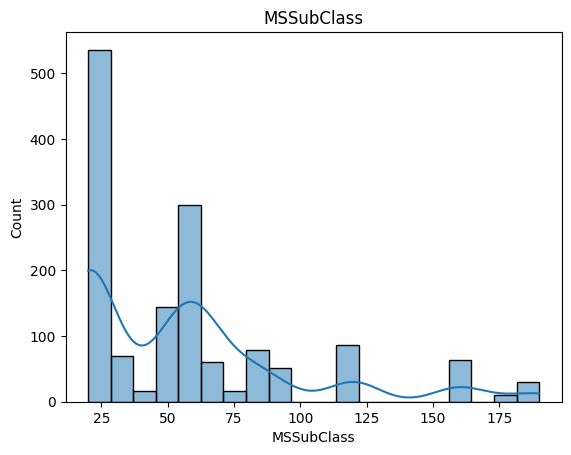

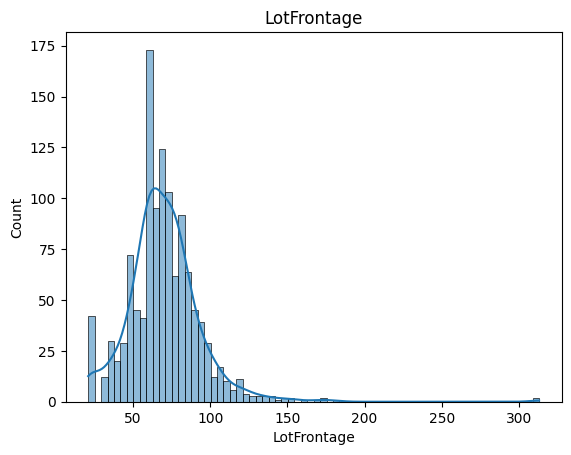

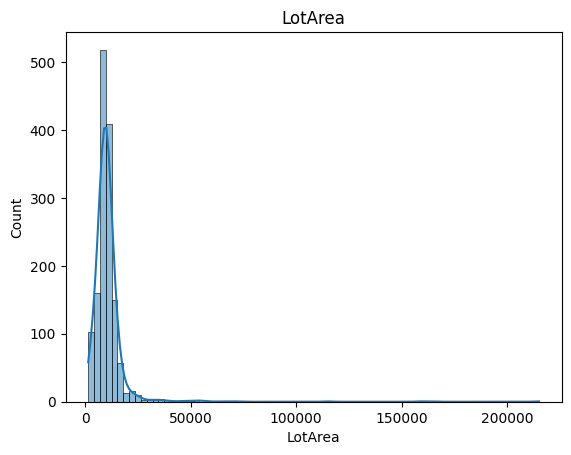

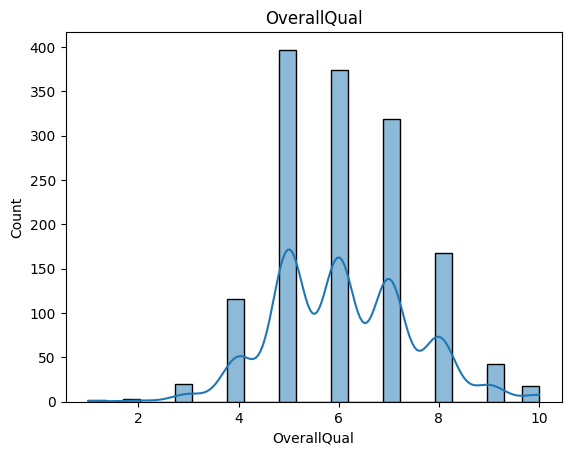

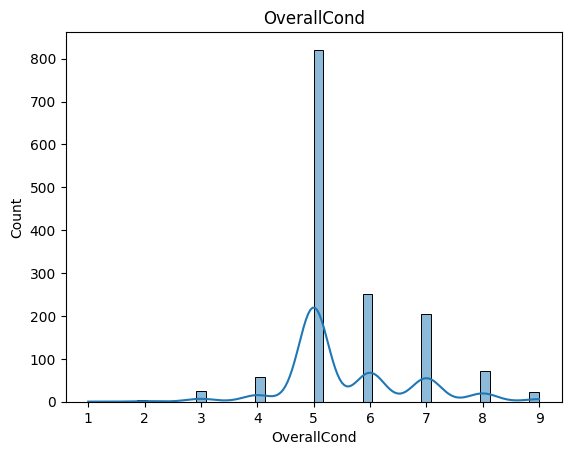

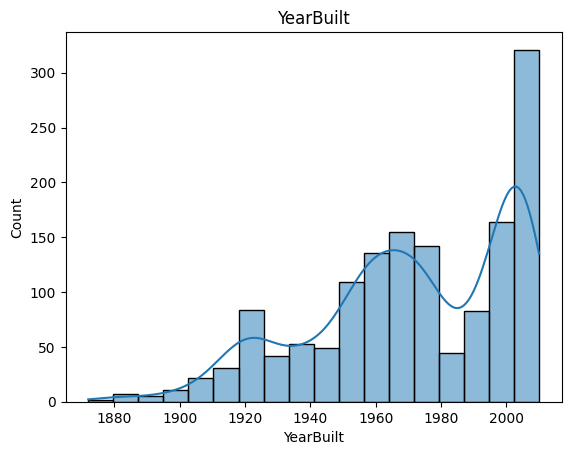

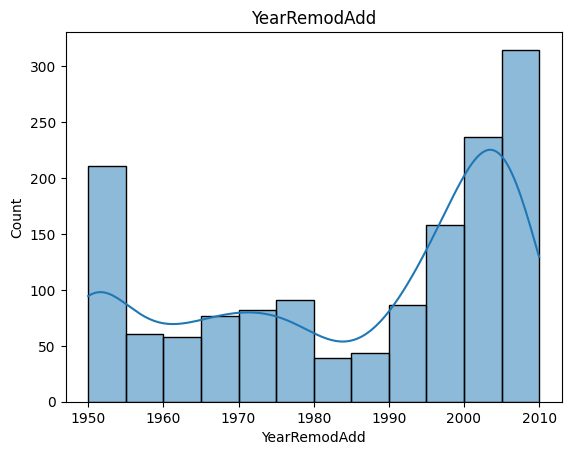

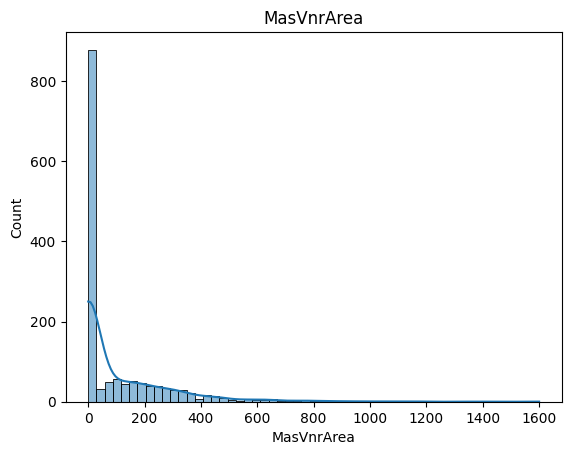

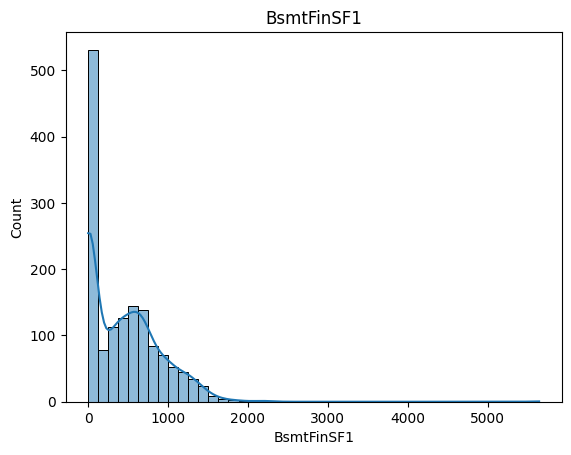

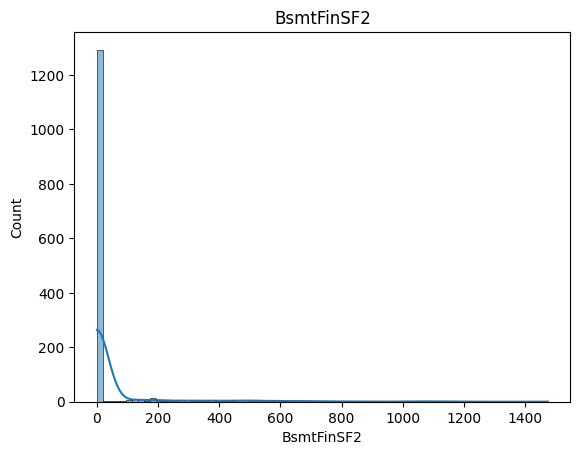

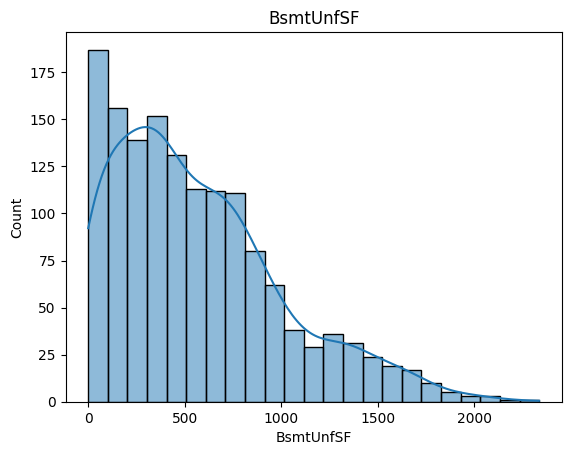

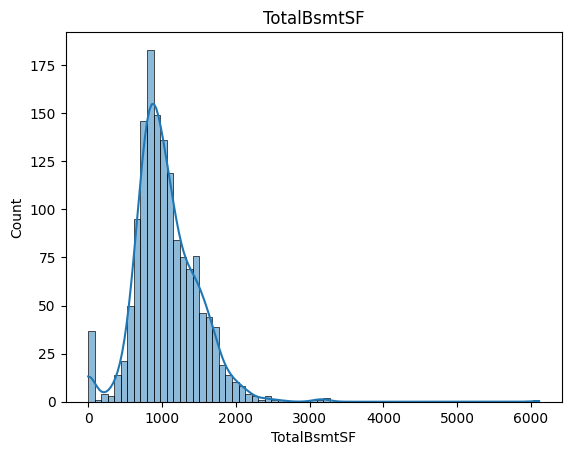

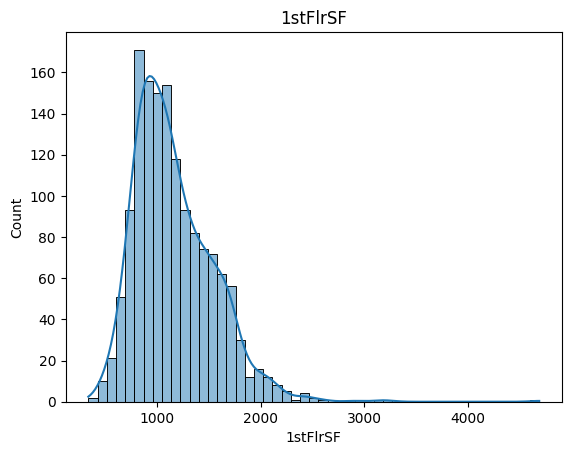

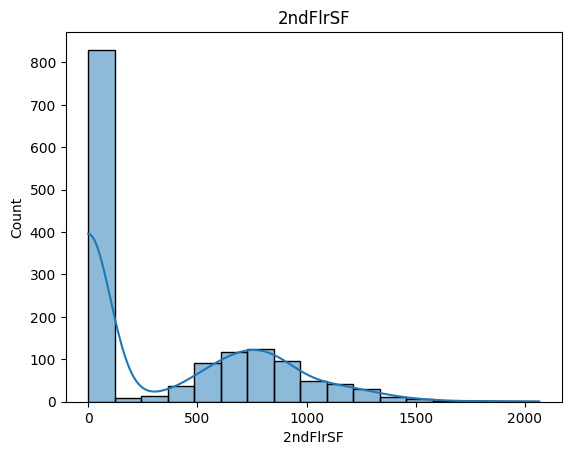

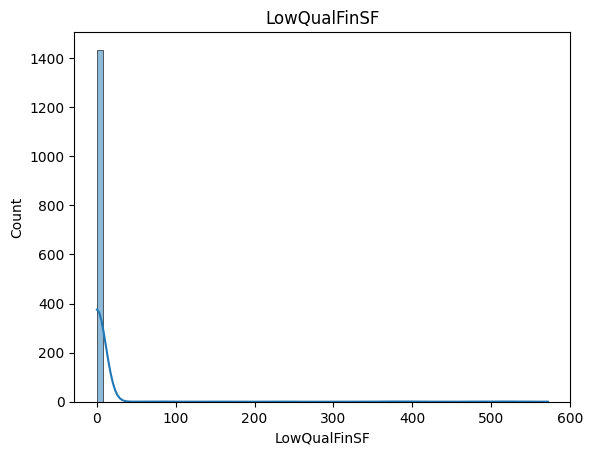

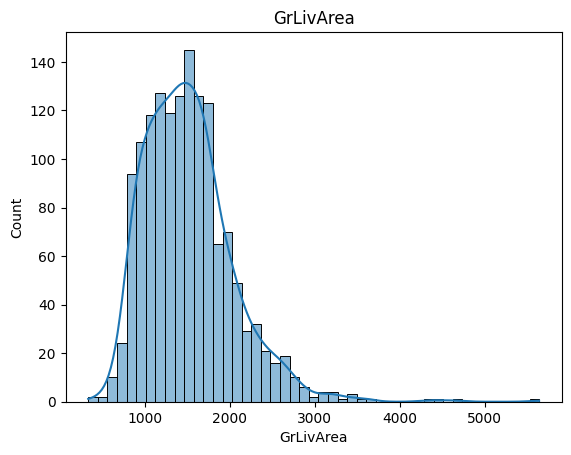

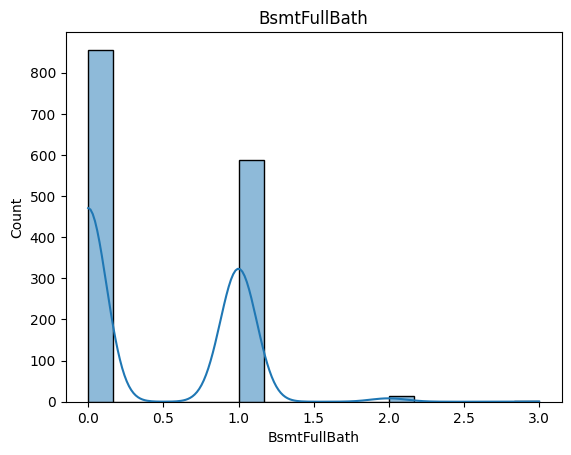

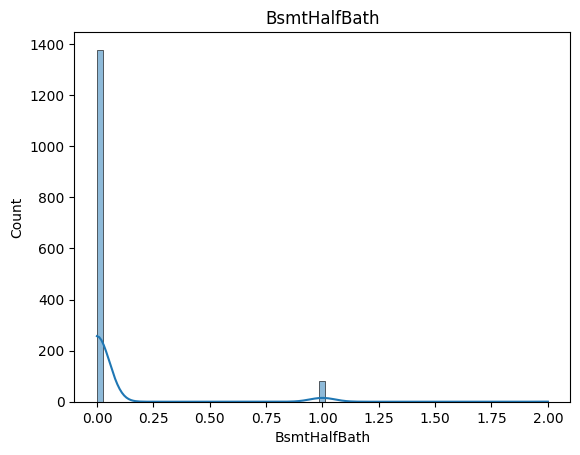

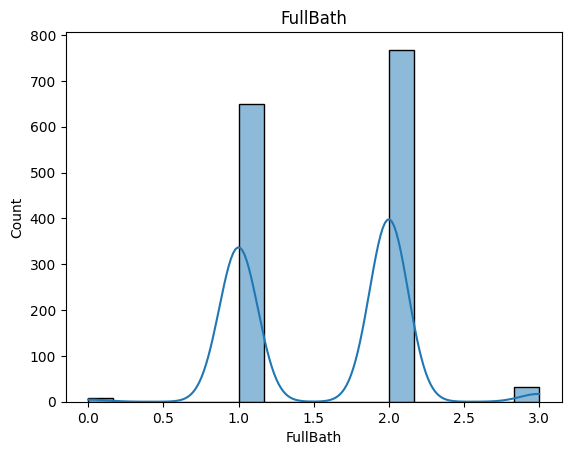

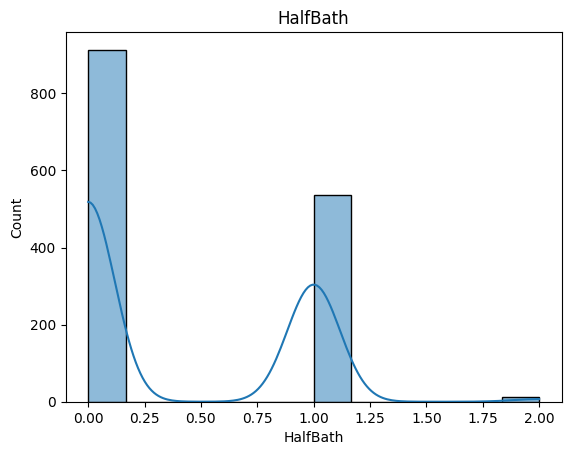

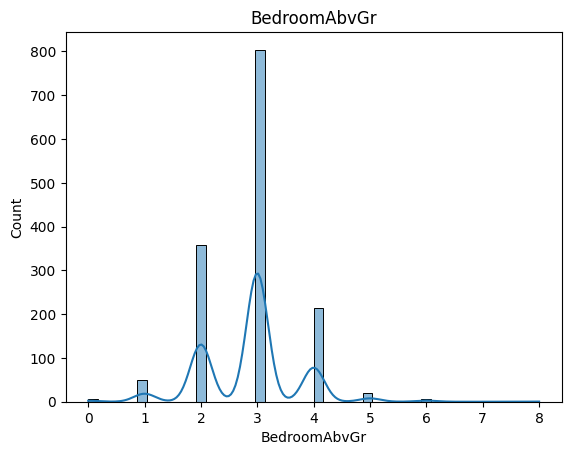

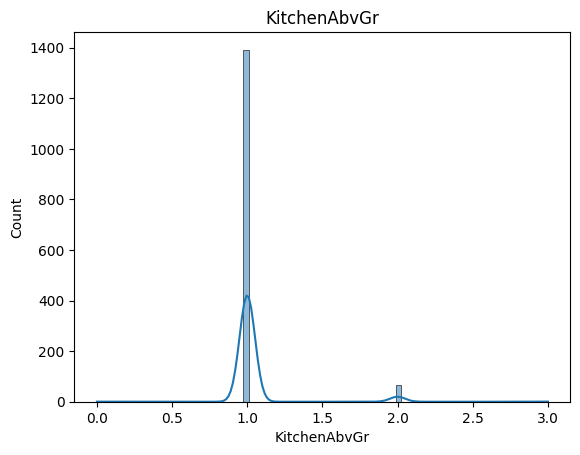

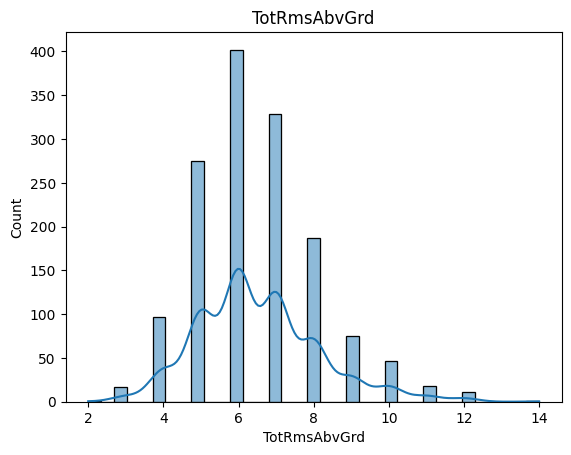

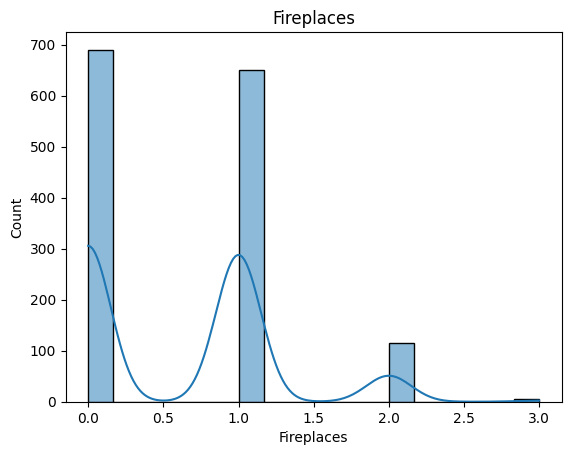

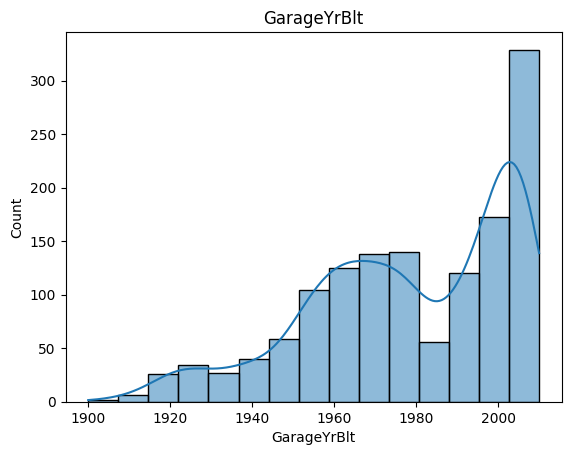

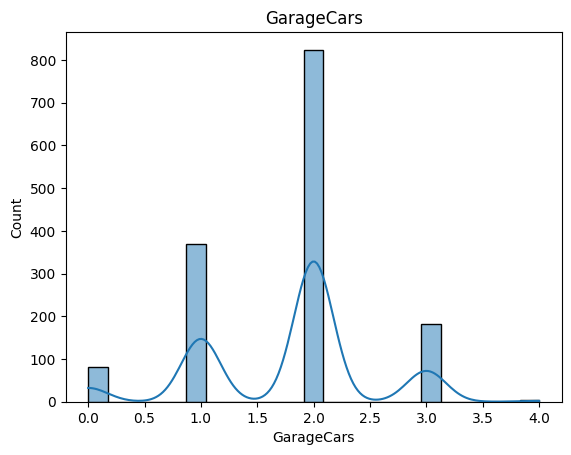

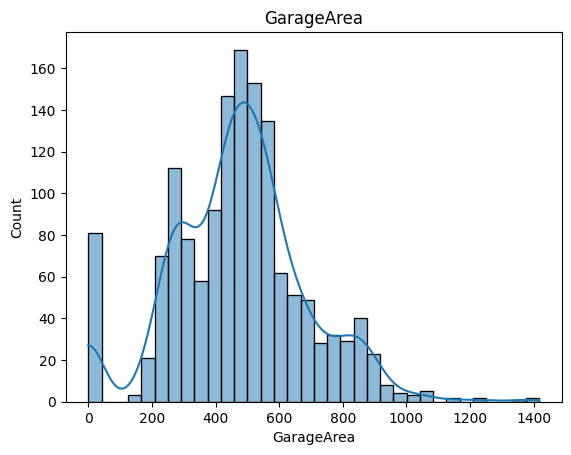

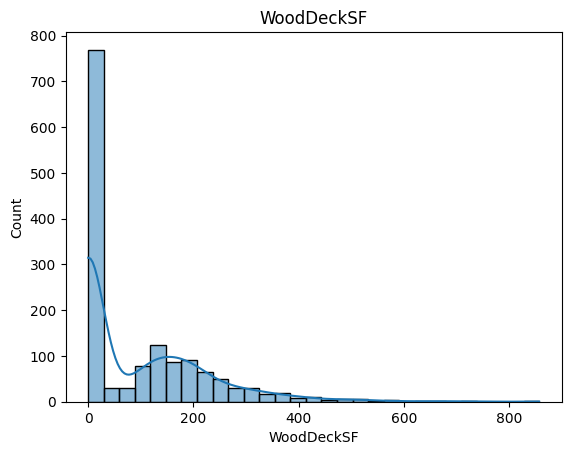

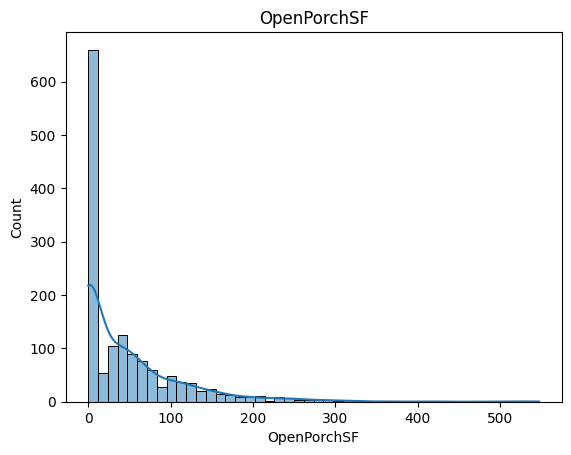

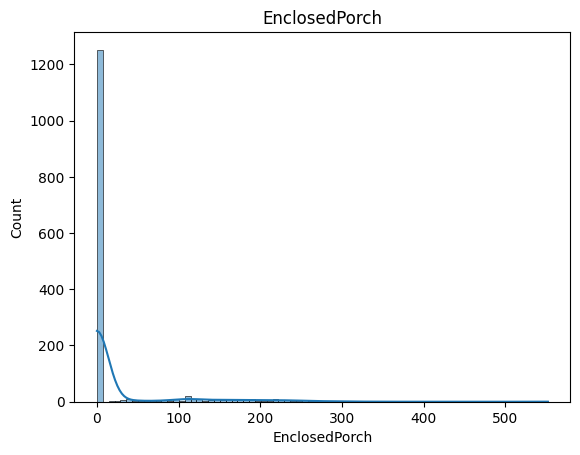

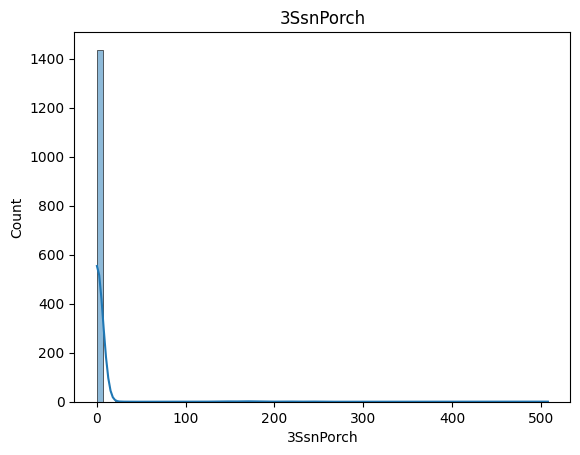

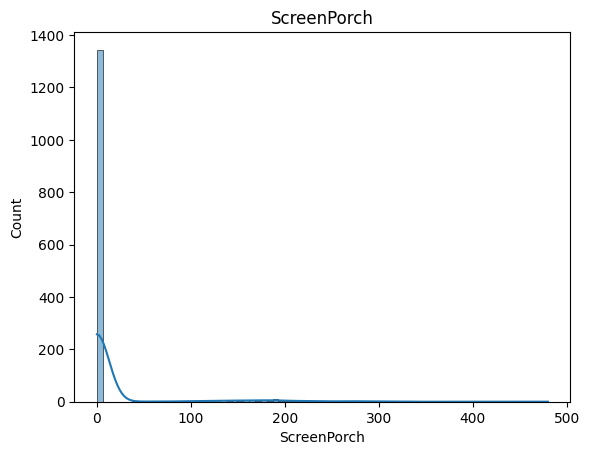

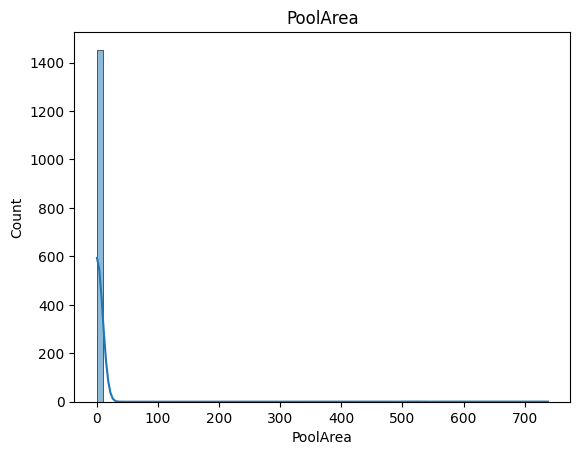

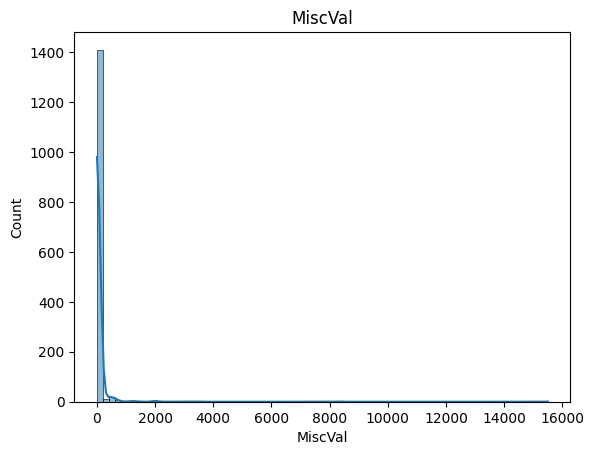

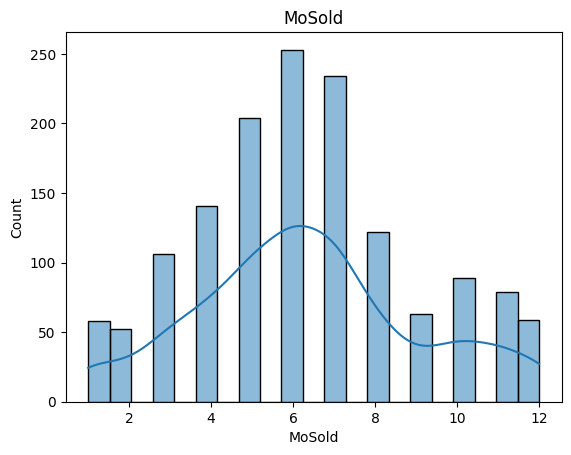

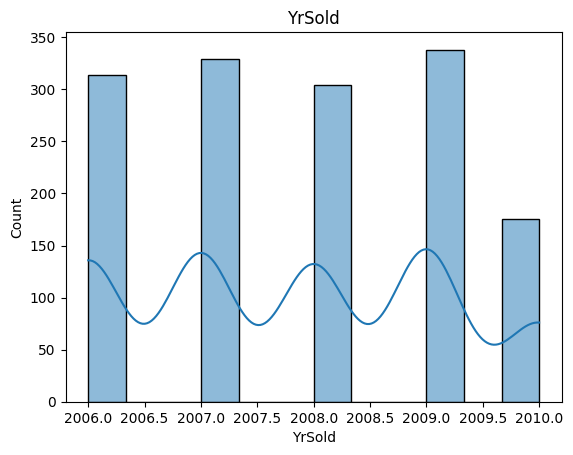

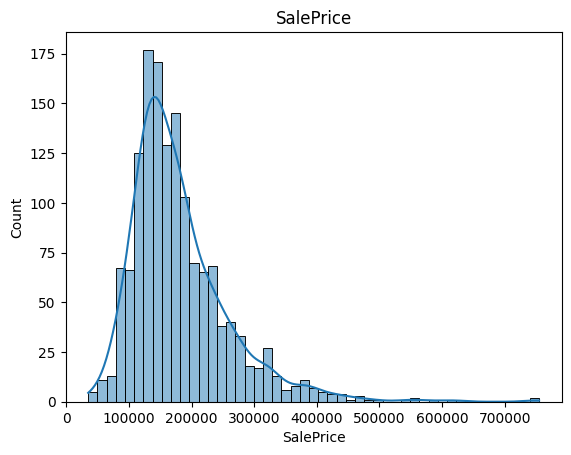

In [14]:
num_cols = train.select_dtypes(include=np.number).columns
for col in num_cols:
    if col!='Id':
        plt.figure()
        sns.histplot(train[col], kde=True)
        plt.title(col)
        plt.show()

## Обзор категориальных признаков

C:\Users\schab\AppData\Local\Temp\ipykernel_7492\335935833.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns


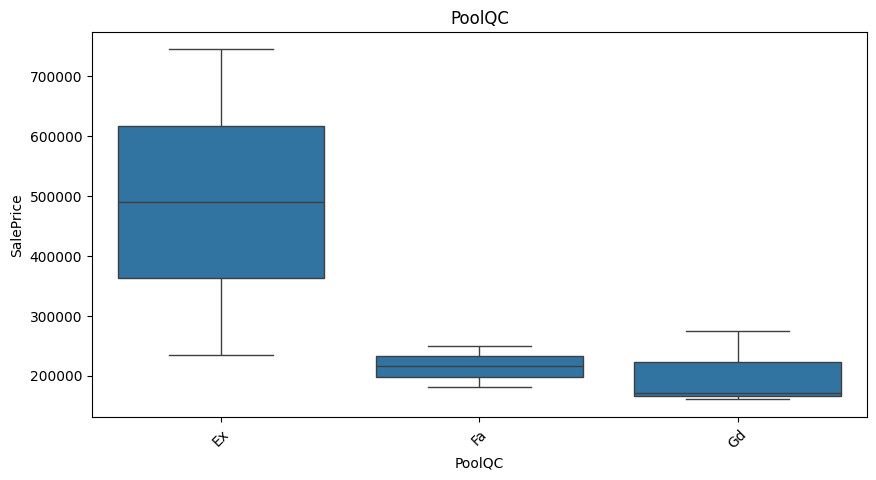

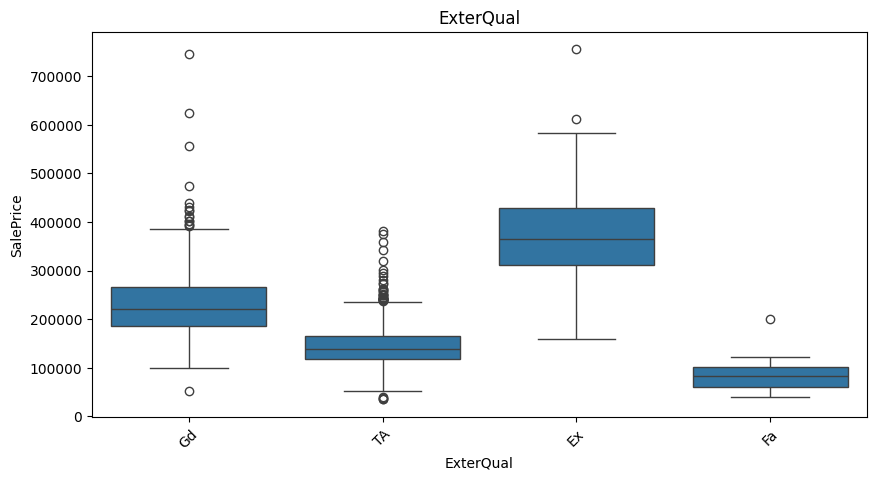

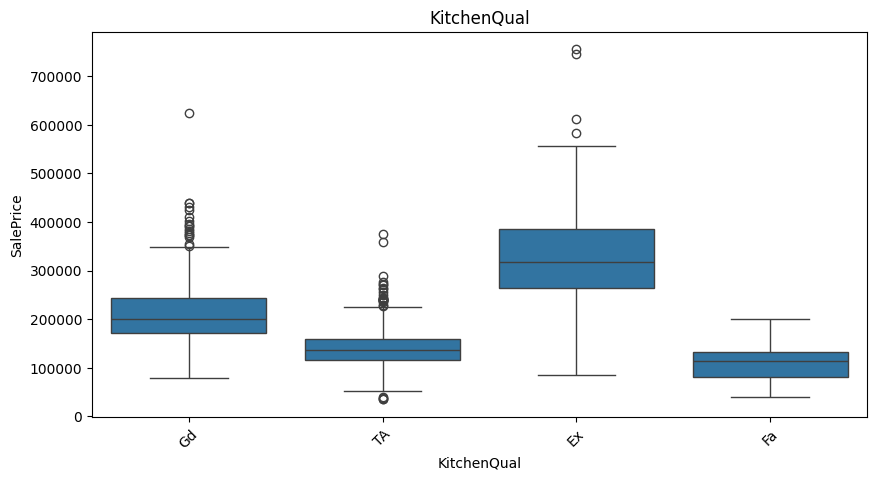

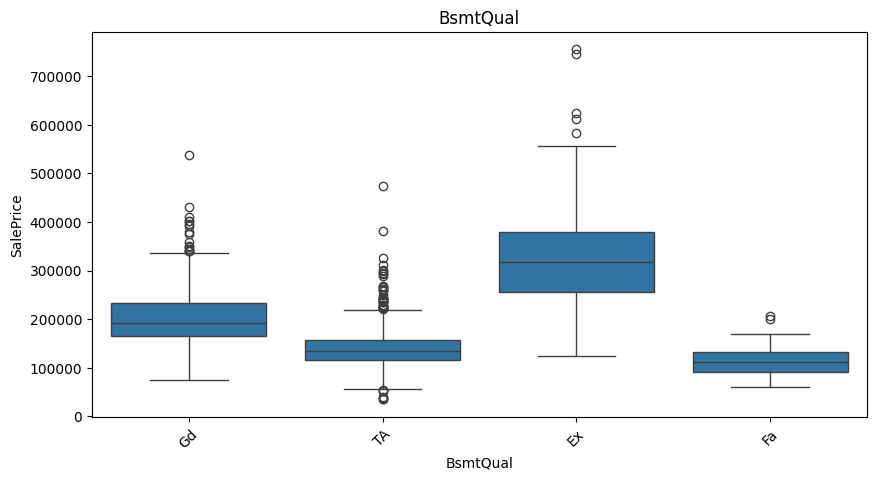

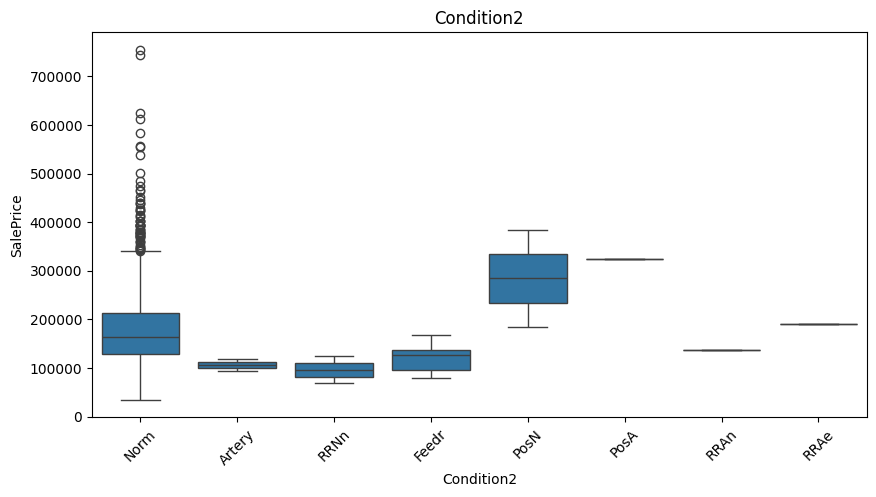

In [15]:
cat_cols = train.select_dtypes(include='object').columns

stats = []

for col in cat_cols:
    grouped = train.groupby(col)['SalePrice'].agg(['mean', 'std', 'count'])
    score = grouped['mean'].std()
    stats.append((col, score))

cat_importance = sorted(stats, key=lambda x: x[1], reverse=True)

top_cat_cols = [col for col, _ in cat_importance[:5]]

for col in top_cat_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y='SalePrice', data=train)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

## Обзор пропусков

In [16]:
none_cols = [
    'PoolQC',      # нет бассейна
    'MiscFeature', # нет доп. объектов
    'Alley',       # нет переулка
    'Fence',       # нет забора
    'FireplaceQu', # нет камина
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',  # нет гаража
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',  # нет подвала
    'MasVnrType',  # нет облицовки
]

zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',  # нет гаража
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',  # нет подвала
    'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea',  # нет облицовки
]

#Пропуски
mode_cols = ['Electrical', 'MSZoning', 'Utilities', 'Functional',
             'Exterior1st', 'Exterior2nd', 'KitchenQual', 'SaleType']

median_cols = ['LotFrontage']  # единственный реальный числовой пропуск

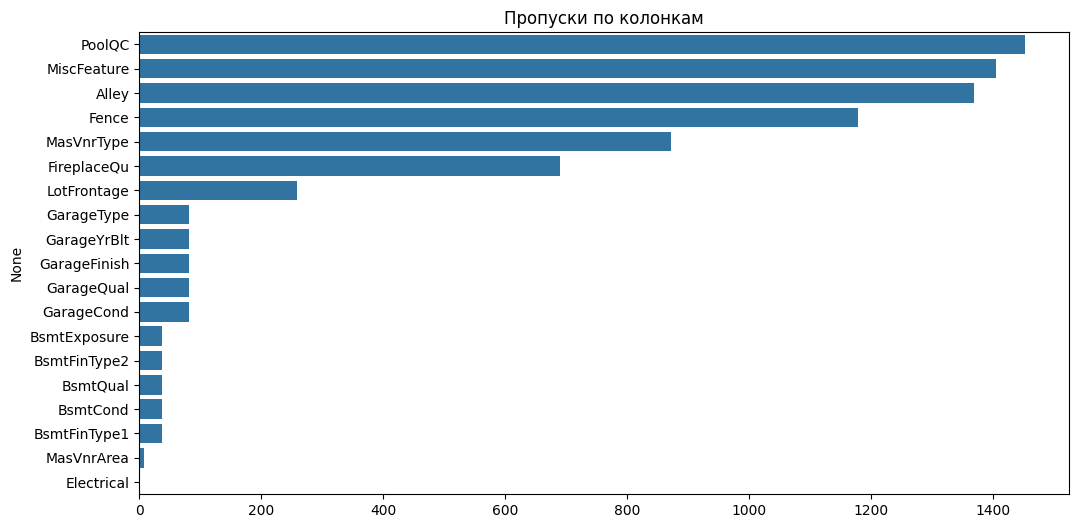

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [17]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing.values, y=missing.index)
plt.title('Пропуски по колонкам')
plt.show()

print(missing)

## Мультиколлинеарность

       feature_1   feature_2  correlation
1015  GarageCars  GarageArea     0.882475


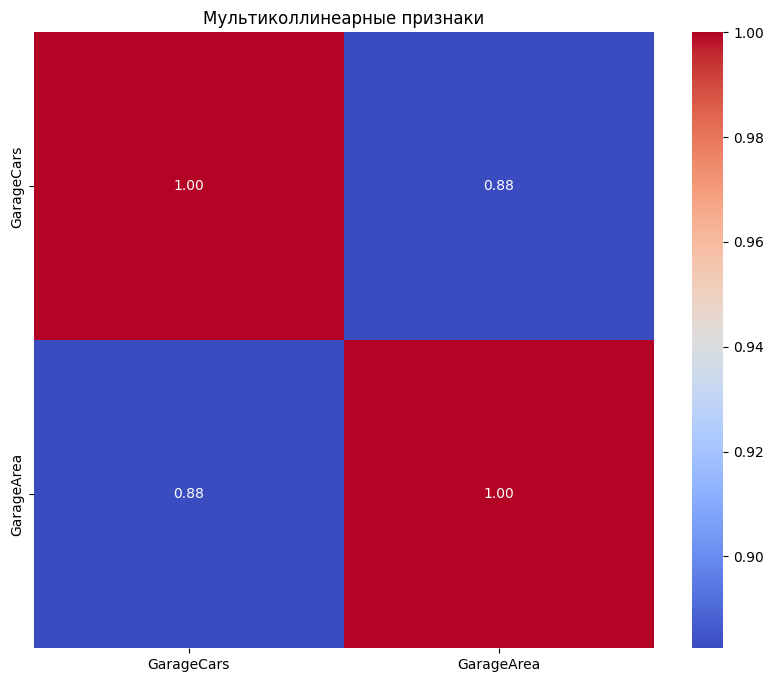

In [18]:
corr_matrix = train.select_dtypes(include='number').corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85
high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
         .query('correlation > @threshold')
         .sort_values('correlation', ascending=False)
)

print(high_corr_pairs)

cols = list(set(high_corr_pairs['feature_1'].tolist() + 
               high_corr_pairs['feature_2'].tolist()))

plt.figure(figsize=(10, 8))
sns.heatmap(train[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Мультиколлинеарные признаки')
plt.show()

In [20]:
zero_heavy = []
for col in train.select_dtypes(include='number').columns:
    zero_ratio = (train[col] == 0).mean()
    if zero_ratio > 0.5:
        zero_heavy.append((col, round(zero_ratio, 2)))

zero_heavy_df = pd.DataFrame(zero_heavy, columns=['feature', 'zero_ratio'])
zero_heavy_df = zero_heavy_df.sort_values('zero_ratio', ascending=False)
print(zero_heavy_df)

          feature  zero_ratio
11       PoolArea        1.00
9       3SsnPorch        0.98
3    LowQualFinSF        0.98
12        MiscVal        0.96
5    BsmtHalfBath        0.94
10    ScreenPorch        0.92
1      BsmtFinSF2        0.89
8   EnclosedPorch        0.86
6        HalfBath        0.63
0      MasVnrArea        0.59
4    BsmtFullBath        0.59
2        2ndFlrSF        0.57
7      WoodDeckSF        0.52


В ходе разведочного анализа было выявлено, что таргет сильно скошен, поэтому было принято решение логарифмировать его.

Сильной корреляции между данными не было обнаружено. Было найдено несколько фичей с высокой корреляцией с таргетом, но критических значений не было найдено. При мультиколлинеарном анализе была найдена 1 пара фичей, обладающей корреляцией выше 0.88. Они обе были связаны с гаражом, однако указывали на разные его параметры, поэтому было принято решение оставить их обе.

Было обнаружено много переменных, имеющих значение 0. То есть отсутсвие чего-то. Для таких переменных было принято решение заменить их на бинарные флаги. После этого изначальные фичи были убраны из набора данных.

Исходя из описания набора данных были отделеные фичи, в которых None идёт не как пропуск, а как отсутсвие чего-то. Это было обработано в ходе предобработки, и пропуски заполнялись только там, где это были именно пропуски.

Часть категориальных данных имела оценочный характер. Для них был использован ordinal encoder с заданным порядком. Для остальных без заданного порядка.